# Document Scanner - 01: Edge Detection & Page Contour

Goal: locate a document (a photographed page) inside a phone-style photo using classic computer vision - no deep learning. This notebook covers the detection half: grayscale, blur, Canny edges, then find the largest 4-corner contour that is the page boundary.

In [1]:
import sys, cv2, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
print('OpenCV', cv2.__version__)

OpenCV 5.0.0


## 1. Load the input photo

A skewed page shot against a darker background.

image shape: (1000, 900, 3)


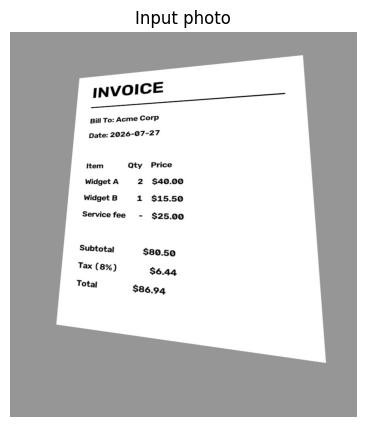

In [2]:
img = utils.load_image('data/document_photo.jpg')
print('image shape:', img.shape)
plt.figure(figsize=(5,5)); plt.imshow(img); plt.title('Input photo'); plt.axis('off'); plt.show()

## 2. Edge map (grayscale -> blur -> Canny -> dilate)

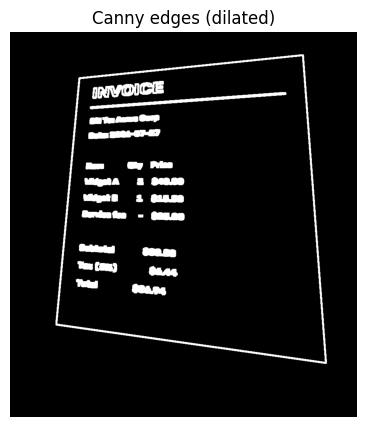

edge pixels: 51297 of 900000


In [3]:
edges = utils.find_edges(img)
plt.figure(figsize=(5,5)); plt.imshow(edges, cmap='gray'); plt.title('Canny edges (dilated)'); plt.axis('off'); plt.show()
print('edge pixels:', int((edges>0).sum()), 'of', edges.size)

## 3. Find the page contour

Keep the 5 largest contours, approximate each polygon, take the first that has exactly 4 corners.

In [4]:
quad = utils.find_document_contour(edges)
print('4-corner contour found:', quad is not None)
if quad is not None:
    area = cv2.contourArea(quad)
    print('contour area: %d px  (%.1f%% of image)' % (area, 100*area/(img.shape[0]*img.shape[1])))
    print('corners (x,y):')
    for p in quad.reshape(4,2): print('  ', tuple(int(v) for v in p))

4-corner contour found: True
contour area: 464567 px  (51.6% of image)
corners (x,y):
   (761, 58)
   (178, 118)
   (118, 761)
   (821, 860)


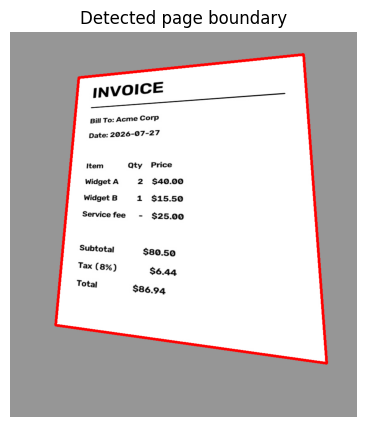

In [5]:
vis = img.copy()
cv2.drawContours(vis, [quad], -1, (255,0,0), 6)
plt.figure(figsize=(5,5)); plt.imshow(vis); plt.title('Detected page boundary'); plt.axis('off'); plt.show()

### Finding
The pipeline recovers a single 4-corner contour covering roughly half the frame - the page. Notebook 02 corrects its perspective and thresholds it into a clean scan.